In [ ]:
# Clone repo (if running in Colab)
!git clone https://github.com/LizaGenke/Chemometric-approaches-to-hyperspectral-processing.git

# Navigate into the cloned repository
%cd Chemometric-approaches-to-hyperspectral-processing

# Install dependencies
!pip install -r requirements.txt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
# Define the path to your data and result folders in Google Drive
# data_path="data"
# results_dir = "results"
data_path = '/content/drive/MyDrive/Chemometrics_Approaches_for_Hyperspectral_Image_Processing/data'
results_dir = '/content/drive/MyDrive/Chemometrics_Approaches_for_Hyperspectral_Image_Processing_Results'
os.makedirs(results_dir, exist_ok=True)

# Fusion of information from multiple sensors

In this notebook, we explore how to combine information from different sensors. Specifically, we focus on the response-oriented sequential alternation (ROSA) method for analyzing multiblock data. ROSA extends partial least squares regression (PLSR) to handle multiple data blocks, allowing sequential modeling of multiblock sensor data for prediction tasks such as estimating rice protein content and milk fat/protein content.

## ROSA: Combining Multiple Data Blocks

The `rosa_pls` function applies PLS block by block. Here's how it works:
1. Start with the full Y.
2. Fit PLS on one block to predict Y.
3. Subtract predictions from Y to get residuals.
4. Orthogonalize the remaining X blocks (so they don’t explain the same thing twice).
5. Repeat for the next block.

This gives us a way to model multiple sensors sequentially.


In [2]:
import numpy as np

class PLS:
    def __init__(self, ncomp, weights=None):
        self.ncomp = ncomp
        self.weights = weights

    def fit(self, X, Y):
        X = np.asarray(X, dtype=np.float64)
        Y = np.asarray(Y, dtype=np.float64)
        n, zp = X.shape
        q = Y.shape[1]

        if self.weights is None:
            self.weights = np.ones(n, dtype=np.float64) / n
        else:
            self.weights = np.asarray(self.weights, dtype=np.float64)
            self.weights = self.weights / np.sum(self.weights)

        self.xmeans = np.sum(self.weights[:, None] * X, axis=0)
        X = X - self.xmeans

        self.ymeans = np.sum(self.weights[:, None] * Y, axis=0)
        Y = Y - self.ymeans

        self.T = np.zeros((n, self.ncomp), dtype=np.float64)
        self.R = np.zeros((zp, self.ncomp), dtype=np.float64)
        self.W = np.zeros((zp, self.ncomp), dtype=np.float64)
        self.P = np.zeros((zp, self.ncomp), dtype=np.float64)
        self.C = np.zeros((q, self.ncomp), dtype=np.float64)
        self.TT = np.zeros(self.ncomp, dtype=np.float64)

        Xd = self.weights[:, None] * X
        tXY = Xd.T @ Y

        for a in range(self.ncomp):
            if q == 1:
                w = tXY[..., 0]
            else:
                # SVD for multi-target Y
                u, _, _ = np.linalg.svd(tXY.T, full_matrices=False)
                u = u[:, 0]
                w = tXY @ u

            w = w / np.sqrt(np.sum(w * w))

            r = w.copy()
            if a > 0:
                for j in range(a):
                    r = r - np.sum(self.P[:, j] * w) * self.R[:, j]

            t = X @ r
            tt = np.sum(self.weights * t * t)

            c = (tXY.T @ r) / tt
            p = (Xd.T @ t) / tt

            tXY = tXY - (p[:, None] @ c[None]) * tt

            self.T[:, a] = t
            self.P[:, a] = p
            self.W[:, a] = w
            self.R[:, a] = r
            self.C[:, a] = c
            self.TT[a] = tt

    def transform(self, X):
        X = np.asarray(X, dtype=np.float64)
        X = X - self.xmeans
        T_new = X @ self.R
        return T_new

    def fit_transform(self, X, Y):
        self.fit(X, Y)
        return self.T

    def get_params(self):
        return {
            "T": self.T,
            "P": self.P,
            "W": self.W,
            "C": self.C,
            "R": self.R,
            "TT": self.TT,
            "xmeans": self.xmeans,
            "ymeans": self.ymeans,
            "weights": self.weights,
            "T.ortorcho": True
        }

    def predict(self, X, nlv=None):
        X = np.asarray(X, dtype=np.float64)
        X = X - self.xmeans

        if nlv is None:
            nlv = self.ncomp
        else:
            nlv = min(nlv, self.ncomp)

        B = self.W[:, :nlv] @ np.linalg.inv(self.P[:, :nlv].T @ self.W[:, :nlv]) @ self.C[:, :nlv].T
        predictions = X @ B + self.ymeans
        return predictions
    
    
def rosa_pls(X_blocks, Y, ncomp_list):
    """
    ROSA-PLS for multiple X blocks using your NumPy PLS class.
    X_blocks: list of np.ndarray, each (n_samples, n_features_block)
    Y: np.ndarray, shape (n_samples, n_targets)
    ncomp_list: list of int, number of components for each block
    Returns: list of dicts with PLS models and predictions for each block
    """
    Y_res = Y.copy()
    X_res_blocks = [X.copy() for X in X_blocks]
    results = []

    for i, (X, ncomp) in enumerate(zip(X_blocks, ncomp_list)):
        pls = PLS(ncomp=ncomp)
        pls.fit(X_res_blocks[i], Y_res)
        Y_pred = pls.predict(X_res_blocks[i], ncomp)
        results.append({
            'pls': pls,
            'Y_pred': Y_pred,
            'block': i
        })
        # Update Y residual for next block
        Y_res = Y_res - Y_pred
        # Orthogonalize next X blocks with respect to current block's scores
        if i < len(X_blocks) - 1:
            T = pls.T[:, :ncomp]  # scores
            for j in range(i+1, len(X_blocks)):
                # Project and remove the part explained by T
                P = np.linalg.pinv(T) @ X_res_blocks[j]
                X_res_blocks[j] = X_res_blocks[j] - T @ P

    return results

## Loading data

We will explore two datasets in this tutorial:

- Rice dataset: three spectra and rice protein content
- Milk fats: three NIR sensor data and fat and protein content as response variables

In [3]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

rice_filepath = f"{data_path}/rice_form.mat"
rice_mat = scipy.io.loadmat(rice_filepath)
milk_filepath = f"{data_path}/milk_fats.mat"
milk_mat = scipy.io.loadmat(milk_filepath)

In [38]:
rice_spectra = rice_mat["sp"]
rice_wavelengths = rice_mat["vars"]
rice_protein = rice_mat["protein"]

In [39]:
milk_spectra = milk_mat["X"]
milk_wavelengths = milk_mat["vars"]
milk_fats = milk_mat["fats"]

In [40]:
list_of_X_blocks_rice = list(rice_spectra[0])
len(list_of_X_blocks_rice)

3

## Applying ROSA for rice protein dataset

We split the data using the **Kennard-Stone algorithm** to ensure the training and test sets cover the full range of input values.

We extract the corresponding parts from all sensor blocks.


In [41]:
import kennard_stone as ks

X_blocks = rice_spectra[0]  
y = rice_protein 

selected_block = X_blocks[0]

X_train, X_test, y_train, y_test = ks.train_test_split(selected_block, rice_protein, test_size=0.2, random_state=1)

def get_indices(X_original, X_subset):
    return np.array([np.where(np.all(np.isclose(X_original, x), axis=1))[0][0] for x in X_subset])

train_idx = get_indices(selected_block, X_train)
test_idx = get_indices(selected_block, X_test)

X_cal_blocks = [block[train_idx] for block in X_blocks]
X_test_blocks = [block[test_idx] for block in X_blocks]
y_cal = rice_protein[train_idx]
y_test = rice_protein[test_idx]

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/kennard_stone/_core/_core.py:313: IgnoredArgumentWarning: `random_state` is unnecessary since it is uniquely determined in this algorithm.
  warnings.warn(
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2025-11-18 13:37:40,897 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2025-11-18 13:37:40,901 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sk

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

def rosa_predict(results, X_new_blocks):
    n_samples_new = X_new_blocks[0].shape[0]
    n_targets = results[0]['pls'].ymeans.shape[0]
    y_pred = np.zeros((n_samples_new, n_targets))
    X_res = [X.copy() for X in X_new_blocks]
    
    for i, res in enumerate(results):
        pls = res['pls']
        ncomp = pls.ncomp
        y_pred += pls.predict(X_res[i], nlv=ncomp)
        
        if i < len(results) - 1:
            T_new = pls.transform(X_res[i])[:, :ncomp]
            for j in range(i + 1, len(X_res)):
                P = np.linalg.pinv(T_new) @ X_res[j]
                X_res[j] -= T_new @ P
    
    return y_pred.ravel() if n_targets == 1 else y_pred

def rosa_cv_rmsep(X_blocks, Y, ncomp_candidates, nfolds=5, random_state=42):
    kf = KFold(n_splits=nfolds, shuffle=True, random_state=random_state)
    best_ncomp = None
    best_rmsep = np.inf
    
    for ncomp_list in ncomp_candidates: 
        errors = []
        for train_idx, val_idx in kf.split(X_blocks[0]):
            X_tr = [X[train_idx] for X in X_blocks]
            Y_tr = Y[train_idx]
            X_val = [X[val_idx] for X in X_blocks]
            Y_val = Y[val_idx]
            
            res = rosa_pls(X_tr, Y_tr, ncomp_list)
            Y_val_pred = rosa_predict(res, X_val)
            
            errors.append(np.sqrt(mean_squared_error(Y_val, Y_val_pred)))
        
        mean_rmsep = np.mean(errors)
        if mean_rmsep < best_rmsep:
            best_rmsep = mean_rmsep
            best_ncomp = ncomp_list
            
    return best_ncomp, best_rmsep

### Choosing the Best Number of Components

We use **K-fold cross-validation** to find the best number of PLS components for each block.

For each combination:
- Fit the model on K-1 folds
- Predict on the remaining fold
- Compute RMSE
- Select the combination with the lowest CV error


In [43]:
from itertools import product

comp_combinations = list(product(range(0,11), repeat=3))
print(comp_combinations)

best_ncomp, best_rmsep = rosa_cv_rmsep(X_cal_blocks, y_cal, comp_combinations) 
print("Best ncomp per block:", best_ncomp)

[(0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 0, 4), (0, 0, 5), (0, 0, 6), (0, 0, 7), (0, 0, 8), (0, 0, 9), (0, 0, 10), (0, 1, 0), (0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 1, 4), (0, 1, 5), (0, 1, 6), (0, 1, 7), (0, 1, 8), (0, 1, 9), (0, 1, 10), (0, 2, 0), (0, 2, 1), (0, 2, 2), (0, 2, 3), (0, 2, 4), (0, 2, 5), (0, 2, 6), (0, 2, 7), (0, 2, 8), (0, 2, 9), (0, 2, 10), (0, 3, 0), (0, 3, 1), (0, 3, 2), (0, 3, 3), (0, 3, 4), (0, 3, 5), (0, 3, 6), (0, 3, 7), (0, 3, 8), (0, 3, 9), (0, 3, 10), (0, 4, 0), (0, 4, 1), (0, 4, 2), (0, 4, 3), (0, 4, 4), (0, 4, 5), (0, 4, 6), (0, 4, 7), (0, 4, 8), (0, 4, 9), (0, 4, 10), (0, 5, 0), (0, 5, 1), (0, 5, 2), (0, 5, 3), (0, 5, 4), (0, 5, 5), (0, 5, 6), (0, 5, 7), (0, 5, 8), (0, 5, 9), (0, 5, 10), (0, 6, 0), (0, 6, 1), (0, 6, 2), (0, 6, 3), (0, 6, 4), (0, 6, 5), (0, 6, 6), (0, 6, 7), (0, 6, 8), (0, 6, 9), (0, 6, 10), (0, 7, 0), (0, 7, 1), (0, 7, 2), (0, 7, 3), (0, 7, 4), (0, 7, 5), (0, 7, 6), (0, 7, 7), (0, 7, 8), (0, 7, 9), (0, 7, 10), (0, 8, 0), (0, 8, 1), (

In [44]:
results = rosa_pls(X_blocks=X_cal_blocks, Y=y_cal, ncomp_list=best_ncomp)

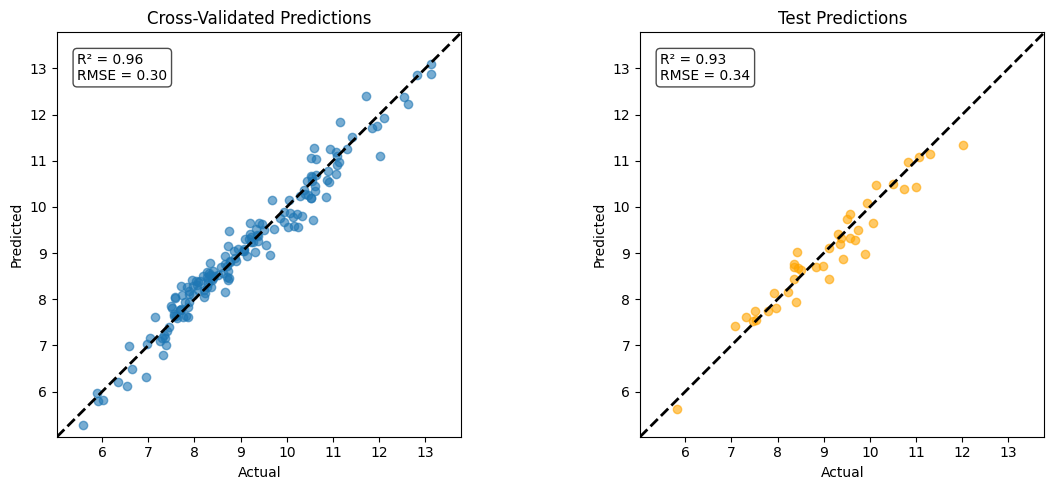

In [45]:
from helperfunctions.plot_functions import plot_cv_vs_test

y_cal_pred = rosa_predict(results, X_cal_blocks)
y_test_pred = rosa_predict(results, X_test_blocks)
plot_cv_vs_test(y_cal, y_cal_pred, y_test, y_test_pred)

## Applying ROSA for the case when of one sensor

Let's see if we can instead of adding data from different sensors work with one and add processed data data as separate blocks.

In [46]:
X_block_1=X_blocks[2]

def snv(input_data):
    # Define a new array and populate it with the corrected data  
    output_data = np.zeros_like(input_data)
    for i in range(input_data.shape[0]):
 
        # Apply correction
        output_data[i,:] = (input_data[i,:] - np.mean(input_data[i,:])) / np.std(input_data[i,:])
 
    return output_data

X_block_2 = snv(X_block_1)

In [47]:
from scipy.signal import savgol_filter
X_block_3 = savgol_filter(X_block_1, window_length=11, polyorder=2, deriv=2, axis=1)

In [48]:
X_blocks = [X_block_1, X_block_2, X_block_3]

selected_block = X_blocks[0]

X_cal_blocks = [block[train_idx] for block in X_blocks]
X_test_blocks = [block[test_idx] for block in X_blocks]
y_cal = y[train_idx]
y_test = y[test_idx]

In [49]:
comp_combinations = list(product(range(0,11), repeat=3))
print(comp_combinations)

best_combo, best_rmsep = rosa_cv_rmsep(X_cal_blocks, y_cal, comp_combinations) 
print("Best ncomp per block:", best_combo)
results = rosa_pls(X_blocks=X_cal_blocks, Y=y_cal, ncomp_list=best_combo)

[(0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 0, 4), (0, 0, 5), (0, 0, 6), (0, 0, 7), (0, 0, 8), (0, 0, 9), (0, 0, 10), (0, 1, 0), (0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 1, 4), (0, 1, 5), (0, 1, 6), (0, 1, 7), (0, 1, 8), (0, 1, 9), (0, 1, 10), (0, 2, 0), (0, 2, 1), (0, 2, 2), (0, 2, 3), (0, 2, 4), (0, 2, 5), (0, 2, 6), (0, 2, 7), (0, 2, 8), (0, 2, 9), (0, 2, 10), (0, 3, 0), (0, 3, 1), (0, 3, 2), (0, 3, 3), (0, 3, 4), (0, 3, 5), (0, 3, 6), (0, 3, 7), (0, 3, 8), (0, 3, 9), (0, 3, 10), (0, 4, 0), (0, 4, 1), (0, 4, 2), (0, 4, 3), (0, 4, 4), (0, 4, 5), (0, 4, 6), (0, 4, 7), (0, 4, 8), (0, 4, 9), (0, 4, 10), (0, 5, 0), (0, 5, 1), (0, 5, 2), (0, 5, 3), (0, 5, 4), (0, 5, 5), (0, 5, 6), (0, 5, 7), (0, 5, 8), (0, 5, 9), (0, 5, 10), (0, 6, 0), (0, 6, 1), (0, 6, 2), (0, 6, 3), (0, 6, 4), (0, 6, 5), (0, 6, 6), (0, 6, 7), (0, 6, 8), (0, 6, 9), (0, 6, 10), (0, 7, 0), (0, 7, 1), (0, 7, 2), (0, 7, 3), (0, 7, 4), (0, 7, 5), (0, 7, 6), (0, 7, 7), (0, 7, 8), (0, 7, 9), (0, 7, 10), (0, 8, 0), (0, 8, 1), (

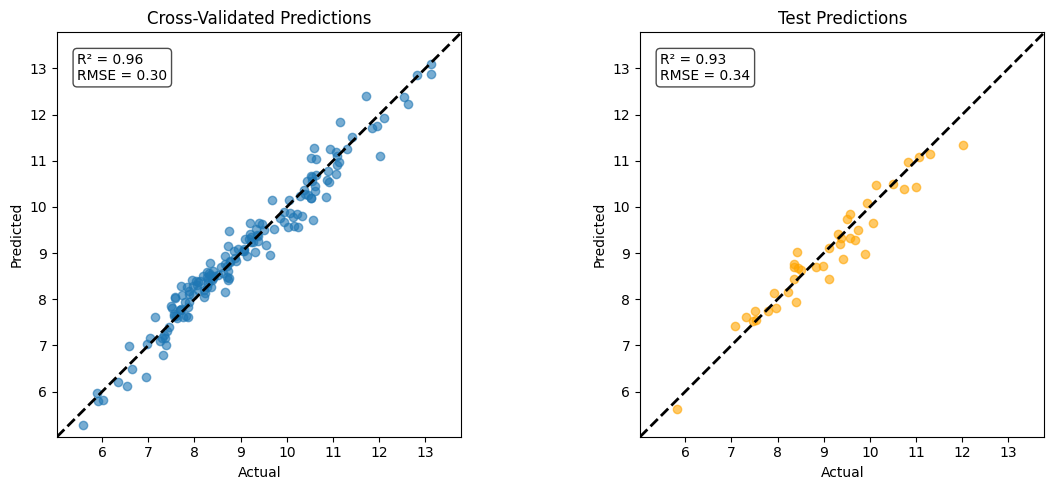

In [50]:
y_cal_pred = rosa_predict(results, X_cal_blocks)
y_test_pred = rosa_predict(results, X_test_blocks)
plot_cv_vs_test(y_cal, y_cal_pred, y_test, y_test_pred)

## Applying ROSA for milk dataset

Let's repeat the same for the milk dataset

In [51]:
import kennard_stone as ks

X_blocks = milk_spectra[0]
X_blocks[1] = X_blocks[1][:, :, 0] # flatten the 3D array to 2D
X_blocks[1], X_blocks[2] = X_blocks[2], X_blocks[1]
y = milk_fats 

selected_block = X_blocks[0]

X_train, X_test, y_train, y_test = ks.train_test_split(selected_block, milk_fats, test_size=0.2, random_state=1)

train_idx = get_indices(selected_block, X_train)
test_idx = get_indices(selected_block, X_test)

X_cal_blocks = [block[train_idx] for block in X_blocks]
X_test_blocks = [block[test_idx] for block in X_blocks]
y_cal = milk_fats[train_idx]
y_test = milk_fats[test_idx]

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/kennard_stone/_core/_core.py:313: IgnoredArgumentWarning: `random_state` is unnecessary since it is uniquely determined in this algorithm.
  warnings.warn(
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2025-11-18 13:38:35,564 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2025-11-18 13:38:35,567 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sk

### Choosing the Best Number of Components

In [52]:
comp_combinations = list(product(range(0,15), repeat=3))
print(comp_combinations)

best_combo, best_rmsep = rosa_cv_rmsep(X_cal_blocks, y_cal, comp_combinations) 
print("Best ncomp per block:", best_combo)

[(0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 0, 4), (0, 0, 5), (0, 0, 6), (0, 0, 7), (0, 0, 8), (0, 0, 9), (0, 0, 10), (0, 0, 11), (0, 0, 12), (0, 0, 13), (0, 0, 14), (0, 1, 0), (0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 1, 4), (0, 1, 5), (0, 1, 6), (0, 1, 7), (0, 1, 8), (0, 1, 9), (0, 1, 10), (0, 1, 11), (0, 1, 12), (0, 1, 13), (0, 1, 14), (0, 2, 0), (0, 2, 1), (0, 2, 2), (0, 2, 3), (0, 2, 4), (0, 2, 5), (0, 2, 6), (0, 2, 7), (0, 2, 8), (0, 2, 9), (0, 2, 10), (0, 2, 11), (0, 2, 12), (0, 2, 13), (0, 2, 14), (0, 3, 0), (0, 3, 1), (0, 3, 2), (0, 3, 3), (0, 3, 4), (0, 3, 5), (0, 3, 6), (0, 3, 7), (0, 3, 8), (0, 3, 9), (0, 3, 10), (0, 3, 11), (0, 3, 12), (0, 3, 13), (0, 3, 14), (0, 4, 0), (0, 4, 1), (0, 4, 2), (0, 4, 3), (0, 4, 4), (0, 4, 5), (0, 4, 6), (0, 4, 7), (0, 4, 8), (0, 4, 9), (0, 4, 10), (0, 4, 11), (0, 4, 12), (0, 4, 13), (0, 4, 14), (0, 5, 0), (0, 5, 1), (0, 5, 2), (0, 5, 3), (0, 5, 4), (0, 5, 5), (0, 5, 6), (0, 5, 7), (0, 5, 8), (0, 5, 9), (0, 5, 10), (0, 5, 11), (0, 5, 12), (0,

In [53]:
results = rosa_pls(X_blocks=X_cal_blocks, Y=y_cal, ncomp_list=best_combo)

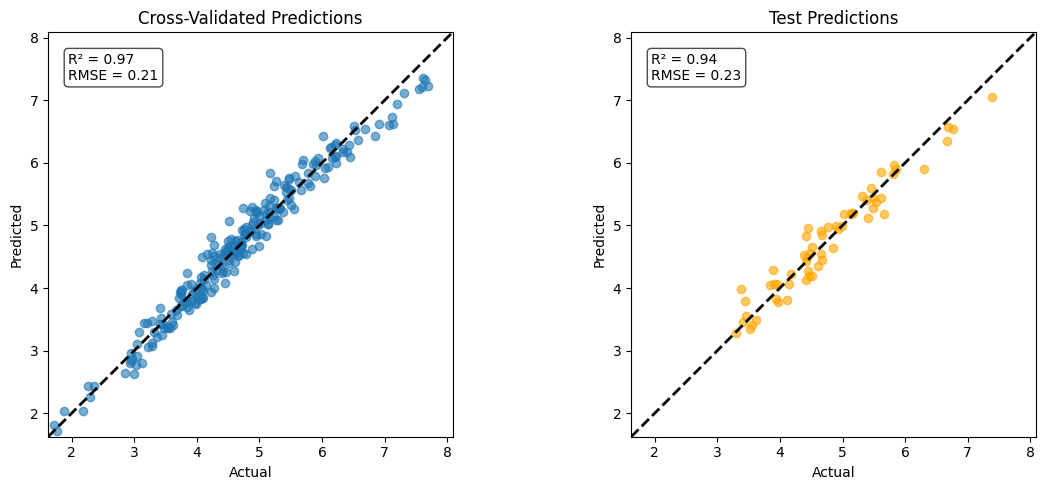

In [54]:
y_cal_pred = rosa_predict(results, X_cal_blocks)
y_test_pred = rosa_predict(results, X_test_blocks)
plot_cv_vs_test(y_cal, y_cal_pred, y_test, y_test_pred)